In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import logging

logging.basicConfig(level=logging.INFO)

from pathlib import Path
import sys
import yaml

# Project root directory
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

# Load project configuration
with open(PROJECT_ROOT / "config.yaml", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# --- Data
from src.data.import_dataframe import import_dataframe
from src.data.merge_pathology_classes import merge_pathology_classes

# --- Features / Analysis
from src.analysis.compute_band_statistics import compute_band_statistics
from src.analysis.aggregate_band_statistics_per_class import aggregate_band_statistics_per_class
from src.analysis.find_most_discriminative_bands import find_most_discriminative_bands
from src.analysis.build_X_y import build_X_y
from src.analysis.threshold_f1_search import threshold_f1_search

# --- Evaluation
from src.evaluation.compute_threshold_metrics import compute_threshold_metrics
from src.evaluation.format_confusion_matrix import format_confusion_matrix
from src.evaluation.save_metrics_csv import save_metrics_csv

# --- Visualization
from src.visualization.plot_mfbm_statistics_per_class import plot_mfbm_statistics_per_class
from src.visualization.plot_band_discriminability import plot_band_discriminability
from src.visualization.plot_threshold_classification import plot_threshold_classification
from src.visualization.plot_and_save_confusion_matrices import plot_and_save_confusion_matrices
from src.visualization.plot_all_classes_std import plot_all_classes_std


In [2]:
# ---------------------------------------------------------
# Load precomputed MFBM features generated by Notebook 1
# ---------------------------------------------------------

dataset_name = config["data"]["corpus_name"]

df = import_dataframe(
    dataset_name,
    input_root=str(PROJECT_ROOT / "data" / "processed")
)


# Inspect dataframe structure
print(df.columns)

Index(['file', 'age', 'gender', 'group', 'class', 'mfbm'], dtype='object')


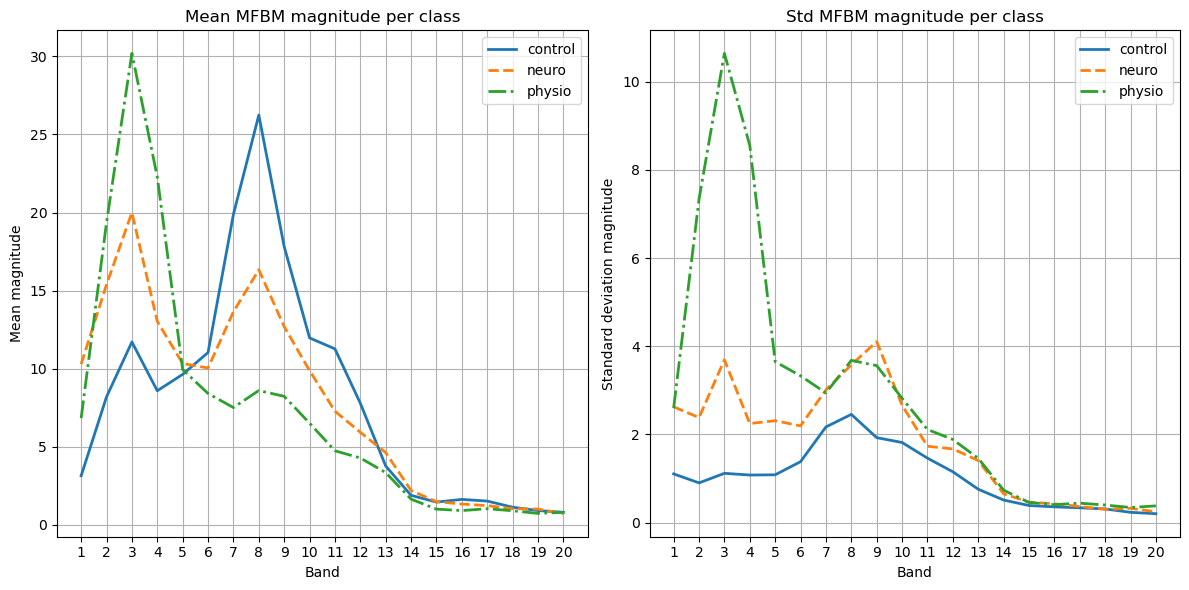

In [3]:
# Compute per-band mean and standard deviation statistics
df = compute_band_statistics(df)

# Merge Reinke's edema and vocal nodules into a single 'physio' class
merge_cfg = config['class_merging']

df = merge_pathology_classes(
    df,
    classes_to_merge=merge_cfg['groups_to_merge'],
    merged_label=merge_cfg['merged_label']
)

# Visualize mean and standard deviation profiles for each class
mean_dict, std_dict = aggregate_band_statistics_per_class(df)
plot_mfbm_statistics_per_class(
    mean_dict, 
    std_dict, 
    save_path="../results/figures/02_mean_std_per_class.png"
)

In [4]:
# Identify the most discriminative MFBM bands for each class pair
db = find_most_discriminative_bands(mean_dict, std_dict)


INFO:src.analysis.find_most_discriminative_bands:control vs neuro: Mean -> band 8, Std -> band 3
INFO:src.analysis.find_most_discriminative_bands:control vs physio: Mean -> band 3, Std -> band 3
INFO:src.analysis.find_most_discriminative_bands:neuro vs physio: Mean -> band 3, Std -> band 3


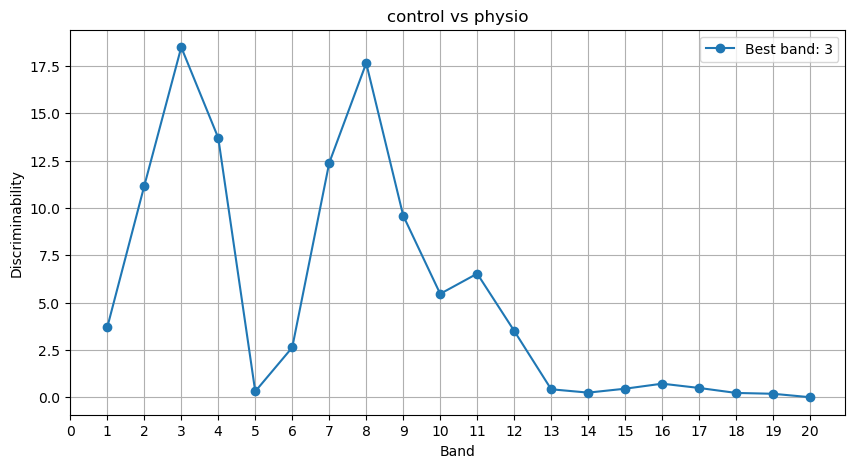

'\nControl vs Physio classes\nIn the original article, the most discriminative band for the mean MFBM features\nwas reported to be band 8. In the present implementation, however, band 3 is\nidentified as the most discriminative between the Control and Physio classes.\n\nThis discrepancy is likely due to small differences in the signal processing\npipeline, numerical precision, or implementation details (e.g., interpolation,\nnormalization, or frame handling). Notably, the discriminability scores of\nbands 3 and 8 are very close, indicating a consistent underlying trend.\n\nFor consistency with the results obtained in the present implementation, the \ndiscriminative bands identified here will be used in the subsequent experiments. \nTherefore, band 3 will be considered the most discriminative mean-MFBM feature for \nthe Control vs Physio comparison\n'

In [5]:
# Visual inspection of band discriminability
plot_band_discriminability(mean_dict, 'control', 'physio')

"""
Control vs Physio classes
In the original article, the most discriminative band for the mean MFBM features
was reported to be band 8. In the present implementation, however, band 3 is
identified as the most discriminative between the Control and Physio classes.

This discrepancy is likely due to small differences in the signal processing
pipeline, numerical precision, or implementation details (e.g., interpolation,
normalization, or frame handling). Notably, the discriminability scores of
bands 3 and 8 are very close, indicating a consistent underlying trend.

For consistency with the results obtained in the present implementation, the 
discriminative bands identified here will be used in the subsequent experiments. 
Therefore, band 3 will be considered the most discriminative mean-MFBM feature for 
the Control vs Physio comparison
"""

In [6]:
# ---------------------------------------------------------
# Binary classification datasets (pairwise class comparisons)
#
# Each feature vector X is defined using:
# - Mean MFBM from the most discriminative band
# - Std  MFBM from the most discriminative band
#
# Band indices are zero-based:
# - Band 7 → 8th Mel band (mean feature)
# - Band 2 → 3rd Mel band (std feature)
# ---------------------------------------------------------


# Control vs Physio
df_12 = df[df['group'].isin(['control', 'physio'])]
X12, y12 = build_X_y(df_12, label_map={'control': 0, 'physio': 1},
                      mean_band=db['control_vs_physio']['mean_band'],
                      std_band=db['control_vs_physio']['std_band'])

# Control vs Neuro
df_13 = df[df['group'].isin(['control', 'neuro'])]
X13, y13 = build_X_y(df_13, label_map={'control': 0, 'neuro': 1},
                      mean_band=db['control_vs_neuro']['mean_band'],
                      std_band=db['control_vs_neuro']['std_band'])

# Physio vs Neuro
df_23 = df[df['group'].isin(['neuro', 'physio'])]
X23, y23 = build_X_y(df_23, label_map={'neuro': 0, 'physio': 1},
                      mean_band=db['neuro_vs_physio']['mean_band'],
                      std_band=db['neuro_vs_physio']['std_band'])

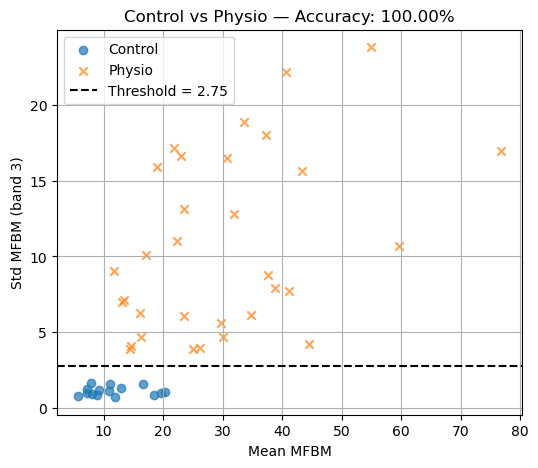

Confusion Matrix:
                   Pred Control   Pred Physio  
True Control  ->         15           0
True Physio   ->          0          32

F1-score: 1.0000
Accuracy: 1.0000


In [7]:
# F1-score is preferred over accuracy due to class imbalance
# control vs physio

t_opt_12 = threshold_f1_search(X12, y12)

cm_12, f1_12, acc_12 = compute_threshold_metrics(X12, y12, t_opt_12)

plot_threshold_classification(
    X12, 
    y12, 
    t_opt_12, 
    acc_12, 
    class_names=('Control', 'Physio'),
    save_path=str(PROJECT_ROOT / config['results']['figures_dir'] / "03_control_vs_physio.png")
)

print(format_confusion_matrix(cm_12, f1_12, acc_12, class_names=('Control', 'Physio')))

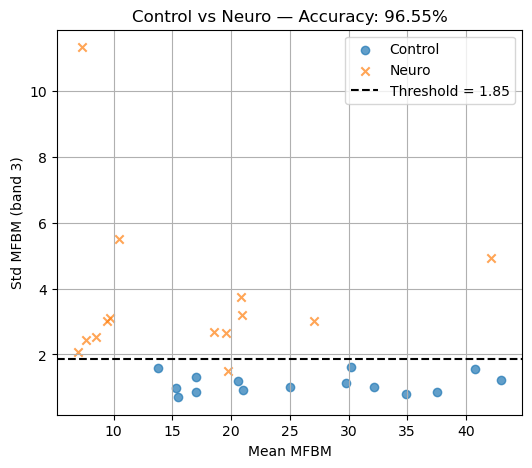

Confusion Matrix:
                   Pred Control   Pred Neuro   
True Control  ->         15           0
True Neuro    ->          1          13

F1-score: 0.9630
Accuracy: 0.9655


In [8]:
# F1-score is preferred over accuracy due to class imbalance
# control vs neuro

t_opt_13 = threshold_f1_search(X13, y13)

cm_13, f1_13, acc_13 = compute_threshold_metrics(X13, y13, t_opt_13)

plot_threshold_classification(
    X13, 
    y13, 
    t_opt_13, 
    acc_13, 
    class_names=('Control', 'Neuro'),
    save_path=str(PROJECT_ROOT / config['results']['figures_dir'] / "03_control_vs_neuro.png")
)

print(format_confusion_matrix(cm_13, f1_13, acc_13, class_names=('Control', 'Neuro')))

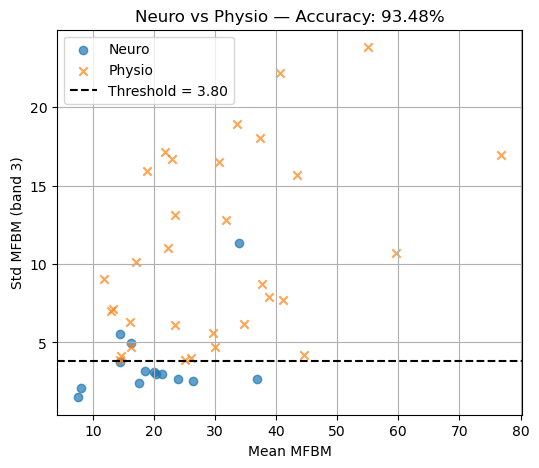

Confusion Matrix:
                   Pred Neuro     Pred Physio  
True Neuro    ->         11           3
True Physio   ->          0          32

F1-score: 0.9552
Accuracy: 0.9348


'\nNote – Physio vs Neuro classification\n\nThe F1-score obtained in the present implementation differs from the value reported in the original \nstudy. This discrepancy is not caused by changes in the classifier or feature extraction pipeline, \nbut rather by the class used as the positive label when computing precision, recall, and F1-score.\n\nIn the original implementation, one class was treated as the positive class, whereas the current \nimplementation follows the default alphabetical ordering of class labels, resulting in the other \nclass being considered positive. Since precision, recall, and F1-score are computed with respect to \nthe positive class, changing the label assignment can lead to different reported values even when \nthe underlying predictions remain unchanged.\n\nAs both classes in this comparison correspond to pathological voice conditions (Physio and Neuro), \nthis difference does not substantially affect the interpretation of the classification performance. \n

In [9]:
# F1-score is preferred over accuracy due to class imbalance
# physio vs neuro

t_opt_23 = threshold_f1_search(X23, y23)

cm_23, f1_23, acc_23 = compute_threshold_metrics(X23, y23, t_opt_23)

plot_threshold_classification(
    X23, 
    y23, 
    t_opt_23, 
    acc_23, 
    class_names=('Neuro', 'Physio'),
    save_path=str(PROJECT_ROOT / config['results']['figures_dir'] / "03_neuro_vs_physio.png")
)

print(format_confusion_matrix(cm_23, f1_23, acc_23, class_names=('Neuro', 'Physio')))

"""
Note – Physio vs Neuro classification

The F1-score obtained in the present implementation differs from the value reported in the original 
study. This discrepancy is not caused by changes in the classifier or feature extraction pipeline, 
but rather by the class used as the positive label when computing precision, recall, and F1-score.

In the original implementation, one class was treated as the positive class, whereas the current 
implementation follows the default alphabetical ordering of class labels, resulting in the other 
class being considered positive. Since precision, recall, and F1-score are computed with respect to 
the positive class, changing the label assignment can lead to different reported values even when 
the underlying predictions remain unchanged.

As both classes in this comparison correspond to pathological voice conditions (Physio and Neuro), 
this difference does not substantially affect the interpretation of the classification performance. 
Nevertheless, it has a measurable impact on the reported precision, recall, and F1-score values, as 
observed in the results.

The reported value of 0.9552 therefore reflects a different positive-class convention rather than an 
improvement in classifier performance.
"""

INFO:src.evaluation.save_metrics_csv:Metrics saved to: C:\Users\ThinK\Desktop\Github Repos\paper-voice-pathology-mfbm\results\metrics\metrics.csv


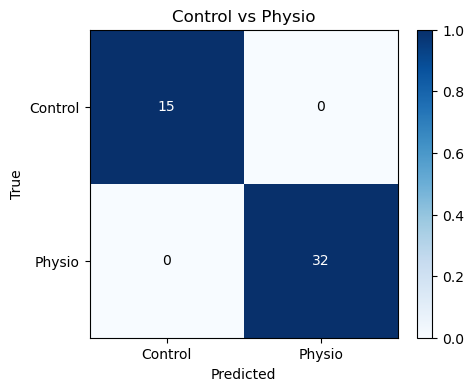

INFO:src.visualization.plot_and_save_confusion_matrices:Saved: C:\Users\ThinK\Desktop\Github Repos\paper-voice-pathology-mfbm\results\figures\04_cm_control_vs_physio.png


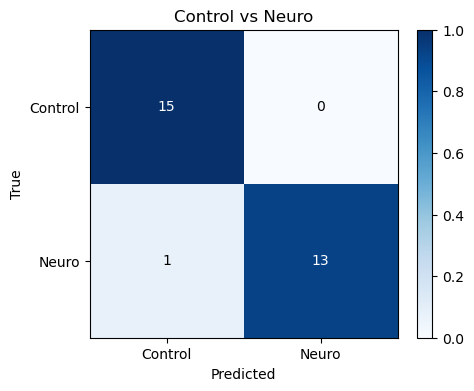

INFO:src.visualization.plot_and_save_confusion_matrices:Saved: C:\Users\ThinK\Desktop\Github Repos\paper-voice-pathology-mfbm\results\figures\04_cm_control_vs_neuro.png


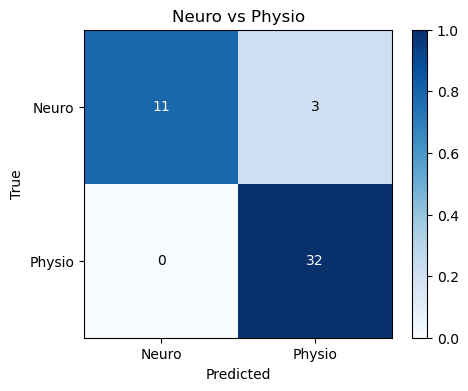

INFO:src.visualization.plot_and_save_confusion_matrices:Saved: C:\Users\ThinK\Desktop\Github Repos\paper-voice-pathology-mfbm\results\figures\04_cm_neuro_vs_physio.png


In [10]:
# Save classification metrics

results = {
    'control_vs_physio': (cm_12, f1_12, acc_12),
    'control_vs_neuro':  (cm_13, f1_13, acc_13),
    'neuro_vs_physio':   (cm_23, f1_23, acc_23)
}

save_metrics_csv(
    results, 
    output_path=str(PROJECT_ROOT / config['results']['metrics_dir'] / "metrics.csv")
)

# Save confusion matrix visualizations

class_names_dict = {
    'control_vs_physio': ('Control', 'Physio'),
    'control_vs_neuro':  ('Control', 'Neuro'),
    'neuro_vs_physio':   ('Neuro', 'Physio')
}

plot_and_save_confusion_matrices(
    results, 
    class_names_dict, 
    output_dir=str(PROJECT_ROOT / config['results']['figures_dir'])
)



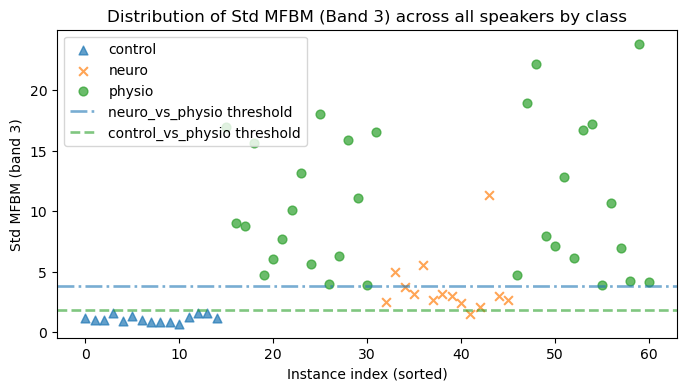

In [12]:
# ---------------------------------------------------------
# Visualize the distribution of the most discriminative
# standard-deviation feature across all classes.
#
# Classification thresholds obtained from the pairwise
# analyses are overlaid for reference.
# ---------------------------------------------------------


thresholds = {
    'neuro_vs_physio': t_opt_23,
    'control_vs_physio': t_opt_13,
}

plot_all_classes_std(
    df,
    std_band=db['control_vs_physio']['std_band'],
    thresholds=thresholds,
    save_path=str(PROJECT_ROOT / config['results']['figures_dir'] / "05_std_distribution_all_classes.png")
)